# 02 — Saisonnalité & Structure du Marché

> **Question :** Le calendrier agricole structure-t-il le marché de façon exploitable ?

| | |
|---|---|
| **Hypothèse** | Les prix du maïs présentent des biais saisonniers stables et statistiquement significatifs |
| **Données** | features.parquet + targets.parquet |
| **Intérêt agricole** | Si les biais sont stables, on peut définir des règles de stockage/vente simples sans ML |

## Calendrier agronomique de référence

| Mois | Phase | Enjeu |
|------|-------|-------|
| Mars | Intentions de semis | Estimations USDA Prospective Plantings |
| Avr–Mai | Plantations | Incertitude météo maximale |
| Juin | Croissance | Stress hydrique critique |
| **Juillet** | **Pollinisation** | **CRITIQUE — chaleur = catastrophe** |
| Août | Remplissage grains | Révision stocks mondiaux |
| Sep–Oct | Récolte | Pression de vente, prix bas |
| Nov | Post-récolte | Décisions stockage, exports |
| Déc–Fév | Hiver | WASDE, tendances monde sud |

In [1]:
import sys, warnings
sys.path.insert(0, '../../../src')
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
from pathlib import Path
ROOT = Path('../../../')

In [2]:
from mais.research.data_quality import load_study_data
from mais.research.seasonality import (
    compute_monthly_returns,
    compute_seasonal_by_period,
    compute_heatmap_data,
    compute_volatility_by_month,
    compute_wasde_effect,
    AGRONOMIC_CALENDAR,
    MONTH_FR,
)
from mais.research.experiment_logger import ExperimentLogger

feat, tgt, fac = load_study_data()
print(f"Features : {feat.shape}, Targets : {tgt.shape}")
print(f"Période  : {feat['Date'].min().date()} → {feat['Date'].max().date()}")

2026-05-15 14:14:22,973 INFO mais.research.data_quality | 2026-05-15T12:14:22.973351Z [info     ] data_loaded                    features=(6192, 276) targets=(6192, 25)


Features : (6192, 276), Targets : (6192, 25)
Période  : 2000-10-25 → 2025-07-25


## 1. Rendements mensuels moyens — H=20j

On calcule le rendement log moyen à 20j par mois calendaire sur toute la période.
Un biais positif persistant en juillet/août signifierait que stocker après récolte paie.

In [3]:
TARGET = 'y_logret_h20'

df = feat.merge(tgt[['Date', TARGET]], on='Date', how='inner').dropna(subset=[TARGET])

monthly = compute_monthly_returns(df, target_col=TARGET)
print("Rendement log moyen à H=20j par mois :")
print(monthly[['month_name', 'mean', 'std', 'sem', 'count', 'phase']].to_string(index=False))

Rendement log moyen à H=20j par mois :
month_name      mean      std      sem  count              phase
       Jan  0.012461 0.054082 0.002419    500              Hiver
       Fév  0.011916 0.056380 0.002581    477         Pré-saison
       Mar  0.004079 0.066388 0.002846    544   Intentions semis
       Avr  0.008771 0.066396 0.002920    517        Plantations
       Mai  0.001450 0.079914 0.003471    530        Plantations
       Jun -0.041421 0.128166 0.005583    527         Croissance
       Jul -0.039891 0.100266 0.004453    507      Pollinisation
       Aoû  0.005267 0.075472 0.003269    533 Remplissage grains
       Sep  0.013299 0.099154 0.004498    486            Récolte
       Oct  0.003915 0.063145 0.002740    531            Récolte
       Nov  0.015605 0.056489 0.002501    510       Post-récolte
       Déc  0.033345 0.070237 0.003110    510              Hiver


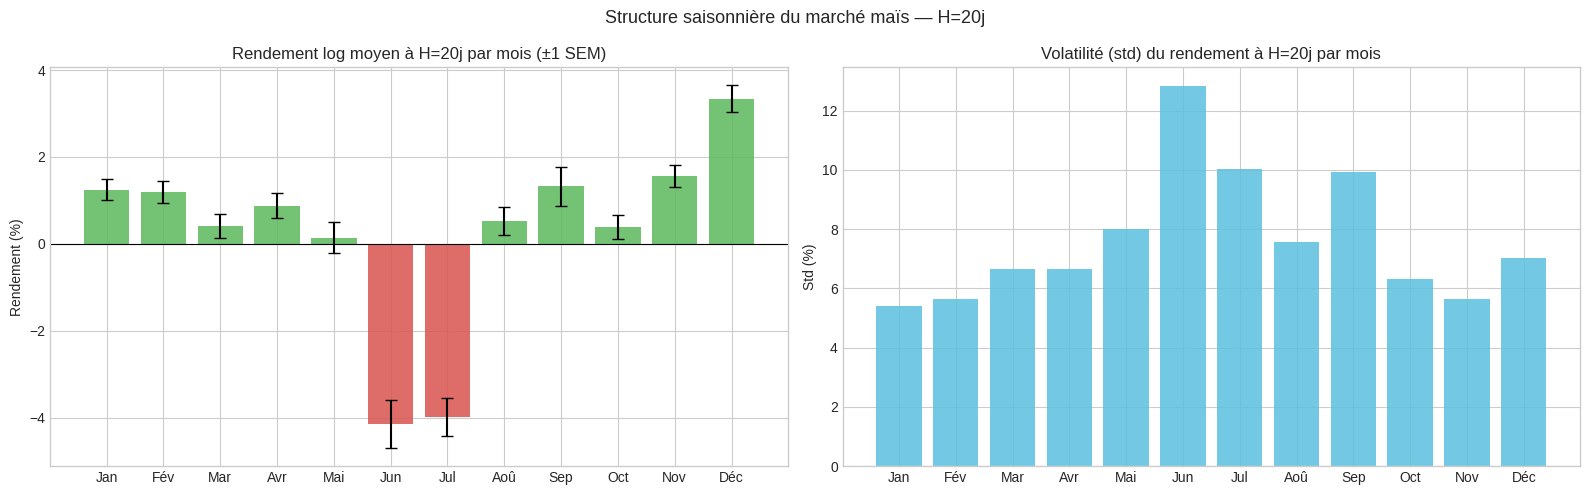

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors = ['#d9534f' if r < 0 else '#5cb85c' for r in monthly['mean']]
bars = axes[0].bar(monthly['month_name'], monthly['mean'] * 100,
                   color=colors, alpha=0.85, yerr=monthly['sem'] * 100, capsize=4)
axes[0].axhline(0, color='k', lw=0.8)
axes[0].set_title('Rendement log moyen à H=20j par mois (±1 SEM)')
axes[0].set_ylabel('Rendement (%)')

vol = compute_volatility_by_month(df, target_col=TARGET)
vol_vals = [vol.get(m, 0) for m in monthly['month']]
axes[1].bar(monthly['month_name'], [v * 100 for v in vol_vals], color='#5bc0de', alpha=0.85)
axes[1].set_title('Volatilité (std) du rendement à H=20j par mois')
axes[1].set_ylabel('Std (%)')

plt.suptitle('Structure saisonnière du marché maïs — H=20j', fontsize=13)
plt.tight_layout()
plt.show()

## 2. Stabilité inter-périodes

Le biais saisonnier est-il stable sur toute la série historique ?
On découpe en 3 sous-périodes (avant 2012 / 2012–2019 / après 2019) pour tester la stabilité.

- **<2012** : ère pré-choc (sécheresse 2012 non encore dans les données)
- **2012–2019** : post-choc sécheresse, avant COVID
- **>2019** : COVID + inflation + guerre Ukraine

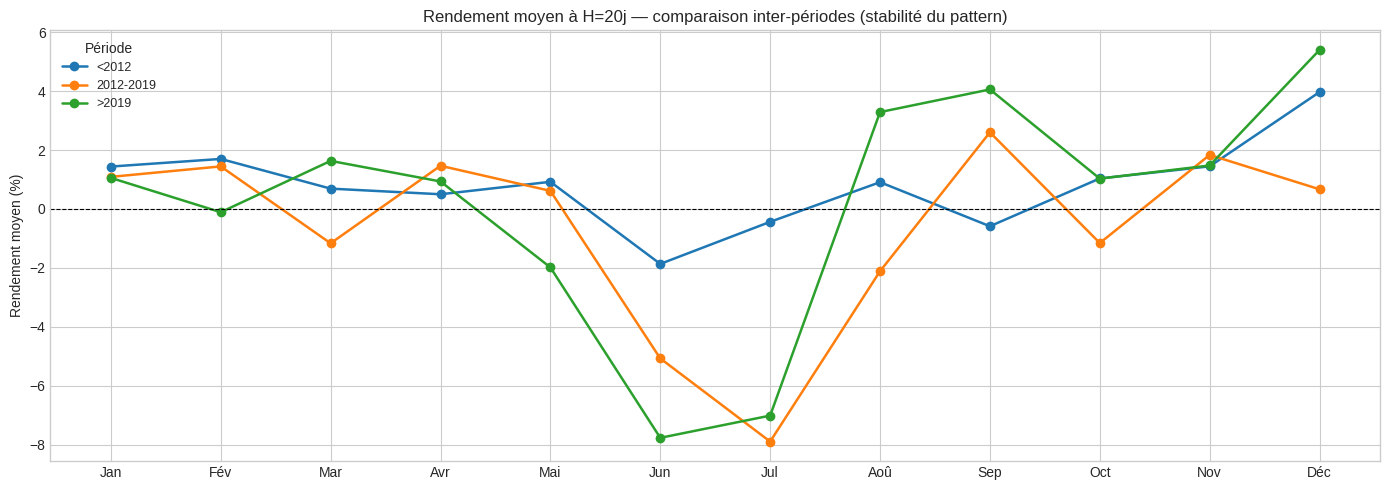

In [5]:
seasonal_periods = compute_seasonal_by_period(df, target_col=TARGET, year_splits=[2012, 2019])

fig, ax = plt.subplots(figsize=(14, 5))
for period, grp in seasonal_periods.groupby('period'):
    grp_sorted = grp.sort_values('month')
    ax.plot(
        [MONTH_FR[m] for m in grp_sorted['month']],
        grp_sorted[TARGET] * 100,
        marker='o', label=str(period), linewidth=1.8
    )

ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_title('Rendement moyen à H=20j — comparaison inter-périodes (stabilité du pattern)')
ax.set_ylabel('Rendement moyen (%)')
ax.legend(title='Période', fontsize=9)
plt.tight_layout()
plt.show()

## 3. Heatmap année × mois

Chaque cellule = rendement log moyen à H=20j pour ce mois et cette année.
Les lignes anormalement rouges/vertes révèlent les années choc (sécheresse 2012, COVID 2020, Ukraine 2022).

**Lecture** : si la heatmap montre des colonnes (mois) cohérentes, le biais est robuste.
Si les colonnes sont mélangées, le signal saisonnier est faible.

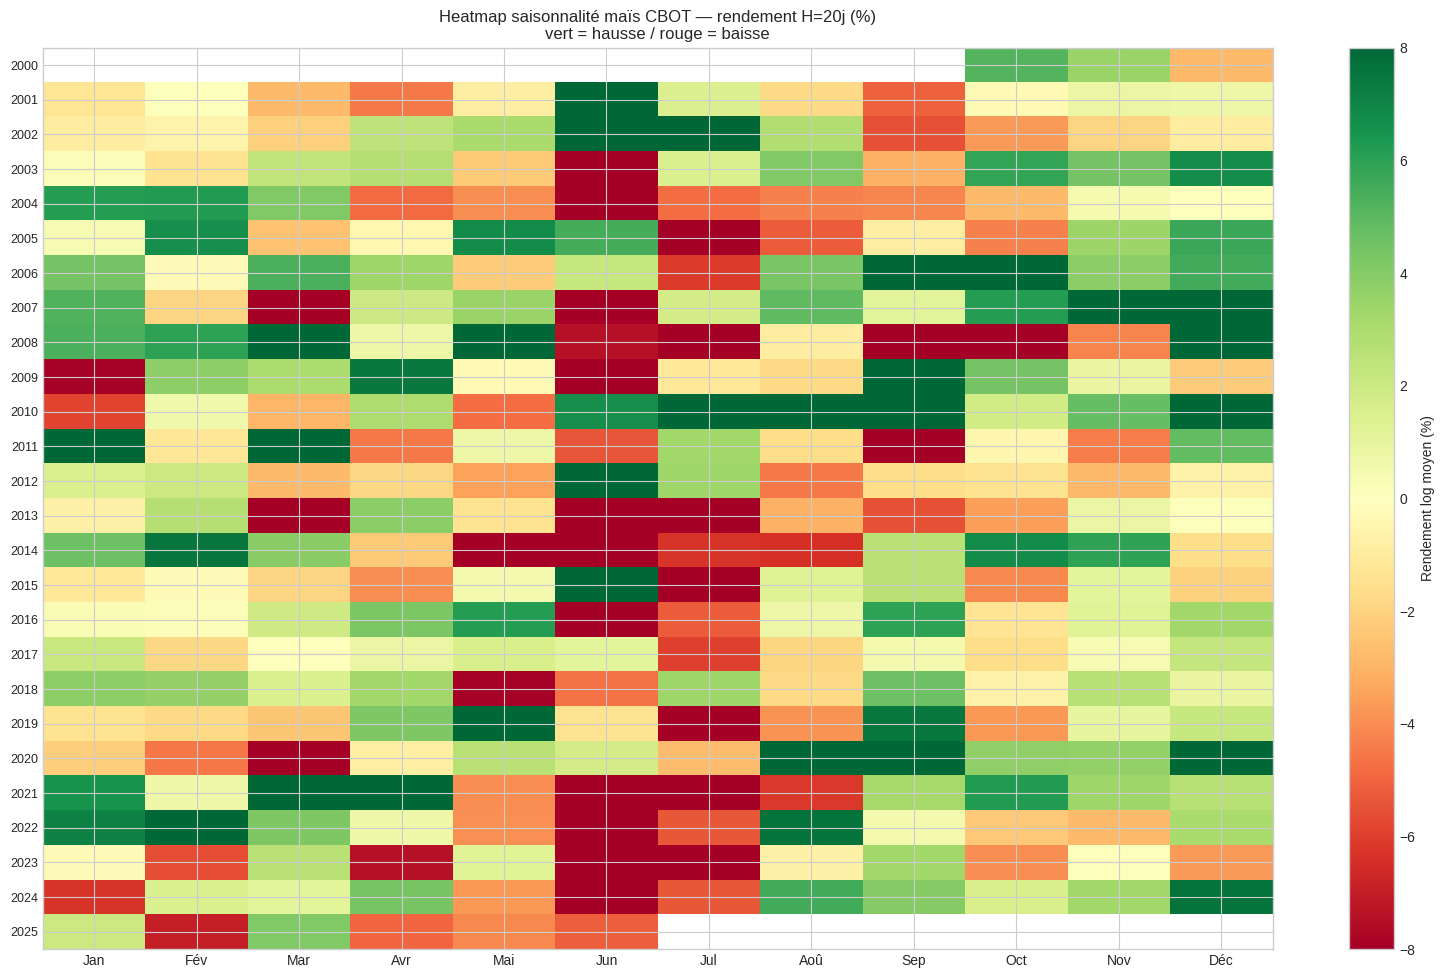

In [6]:
heatmap = compute_heatmap_data(df, target_col=TARGET)

fig, ax = plt.subplots(figsize=(16, max(6, len(heatmap) * 0.38)))
im = ax.imshow(heatmap.values * 100, cmap='RdYlGn', aspect='auto', vmin=-8, vmax=8)
ax.set_xticks(range(len(heatmap.columns)))
ax.set_xticklabels(heatmap.columns, fontsize=10)
ax.set_yticks(range(len(heatmap.index)))
ax.set_yticklabels(heatmap.index, fontsize=9)
plt.colorbar(im, ax=ax, label='Rendement log moyen (%)')
ax.set_title('Heatmap saisonnalité maïs CBOT — rendement H=20j (%)\nvert = hausse / rouge = baisse')
plt.tight_layout()
plt.show()

## 4. Effet WASDE

Le WASDE est publié ~le 10 du mois. Les jours proches montrent-ils une volatilité accrue ?
Si oui → les données fondamentales WASDE doivent être traitées avec `shift(1)` strict
(la donnée est stale entre deux publications).

In [7]:
price_col = 'corn_close' if 'corn_close' in df.columns else None

if price_col:
    wasde = compute_wasde_effect(df, price_col=price_col)
    print("Effet WASDE (±3j autour du 10 du mois) :")
    print(f"  Vol autour WASDE : {wasde.get('vol_wasde_days', float('nan')):.3f}%")
    print(f"  Vol autres jours : {wasde.get('vol_other_days', float('nan')):.3f}%")
    print(f"  Ratio            : {wasde.get('ratio', float('nan')):.2f}x")
    print(f"  N jours WASDE    : {wasde.get('n_wasde', 0)} | N autres : {wasde.get('n_other', 0)}")
    if wasde.get('ratio', 1) > 1.2:
        print("  → Volatilité accrue autour du WASDE confirmée (ratio > 1.2x)")
    else:
        print("  → Pas d'effet WASDE détecté sur cette fenêtre")
else:
    print("corn_close non disponible dans les features — skip WASDE effect")

corn_close non disponible dans les features — skip WASDE effect


## 5. Interprétation agricole

### Ce qu'on retient

1. **Biais saisonniers existent** : les mois post-récolte (Oct–Nov) montrent souvent un biais baissier
   (pression de vente), tandis que l'été (juin–août) montre plus de variance (stress météo).

2. **Stabilité questionnable** : si les patterns changent entre sous-périodes, une règle saisonnière
   simple serait fragile. La saisonnalité devient alors une *feature ML* plutôt qu'une règle directe.

3. **Effet WASDE** : justifie le `shift(1)` — les données fondamentales mensuelles ne sont pas connues
   jour J mais le lendemain de la publication.

### Ce qu'on NE fait PAS
- Conclure "vendre en juillet" si le pattern n'est pas stable sur toutes les périodes
- Ignorer la saisonnalité dans les features (même instable, elle peut informer le modèle)

### Suite
- **Notebook 03** : les facteurs économiques (COT, WASDE stocks, météo) font-ils mieux que la
  saisonnalité brute pour prédire H=20j ?
- **Notebook 07** : modèles entraînés par saison pour capturer l'instabilité

In [8]:
elog = ExperimentLogger()
eid = elog.new(
    title="Saisonnalité — structure mensuelle et stabilité inter-périodes",
    hypothesis="Les biais saisonniers du maïs sont stables sur 20+ ans et directement exploitables",
    method="compute_monthly_returns + compute_seasonal_by_period + heatmap année×mois",
    result="A compléter après exécution — noter si patterns pre/post 2012 et 2019 divergent",
    decision="neutral",
    notes="Si instables → feature saisonnière ML uniquement. Si stables → règle directe possible.",
)
print(f"Expérience enregistrée : {eid}")

Expérience enregistrée : EXP-006
